In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

matplotlib.rcParams["font.family"]        = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# 데이터 로드
master_df  = pd.read_csv("data/master_dataset.csv",  index_col=0, parse_dates=True)
metrics_s  = pd.read_csv("data/financial_metrics.csv", index_col=0).squeeze()
pred_df    = pd.read_csv("data/ml_predictions.csv",   index_col=0, parse_dates=True)

STOCK_COLS = ["삼성전자", "SK하이닉스", "NAVER", "KODEX200", "KODEX채권"]
WEIGHTS    = np.array([0.25, 0.20, 0.20, 0.25, 0.10])
CONFIDENCE = 0.95
INVESTMENT = 100_000_000

portfolio_returns = (master_df[STOCK_COLS] * WEIGHTS).sum(axis=1)
var_threshold     = np.percentile(portfolio_returns, (1 - CONFIDENCE) * 100)

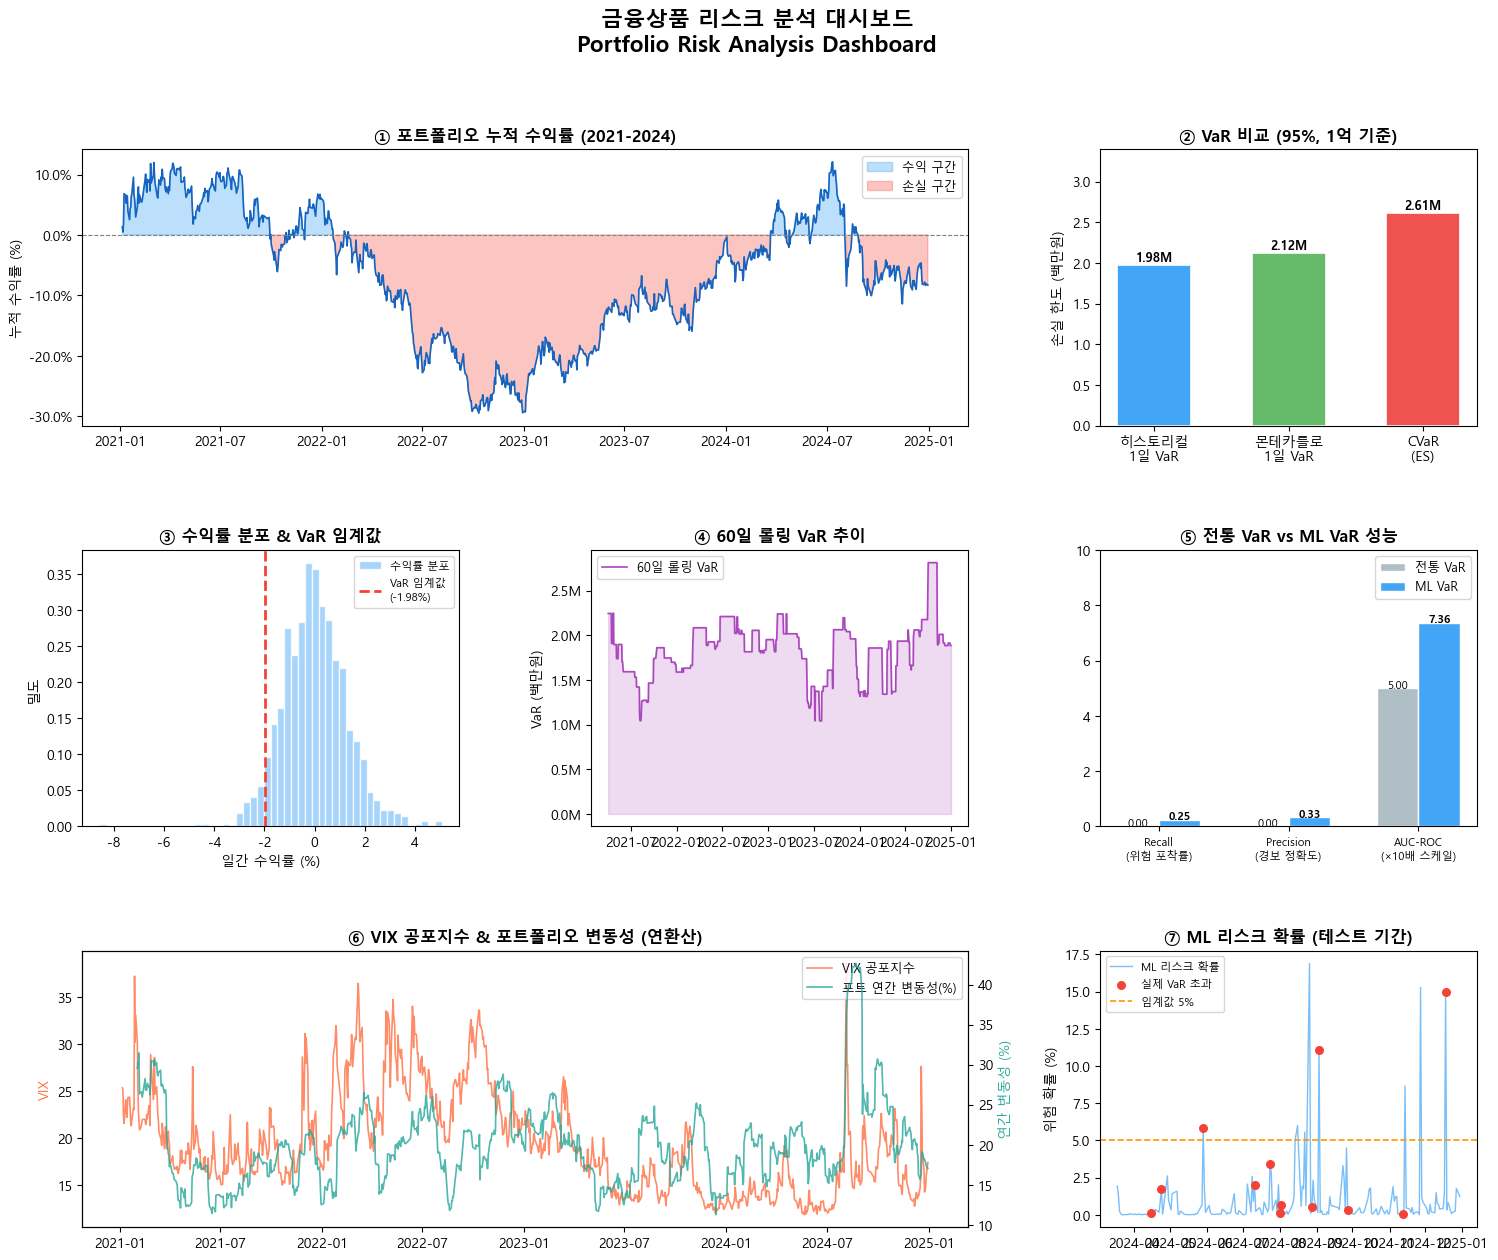

✅ 대시보드 저장 완료: data/dashboard.png


In [ ]:
# Figure 1 — 6분할 메인 대시보드
# ════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 14))
fig.suptitle("금융상품 리스크 분석 대시보드\nPortfolio Risk Analysis Dashboard",
             fontsize=16, fontweight="bold", y=0.98)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# [1,1] 포트폴리오 누적 수익률
ax1 = fig.add_subplot(gs[0, :2])
cum_ret = (1 + portfolio_returns).cumprod() - 1
ax1.fill_between(cum_ret.index, cum_ret * 100, 0,
                 where=cum_ret >= 0, color="#2196F3", alpha=0.3, label="수익 구간")
ax1.fill_between(cum_ret.index, cum_ret * 100, 0,
                 where=cum_ret < 0,  color="#F44336", alpha=0.3, label="손실 구간")
ax1.plot(cum_ret.index, cum_ret * 100, color="#1565C0", linewidth=1.2)
ax1.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax1.set_title("① 포트폴리오 누적 수익률 (2021-2024)", fontweight="bold")
ax1.set_ylabel("누적 수익률 (%)")
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))

# [1,3] VaR 비교 바 차트 
ax2  = fig.add_subplot(gs[0, 2])
labels = ["히스토리컬\n1일 VaR", "몬테카를로\n1일 VaR", "CVaR\n(ES)"]
values = [
    metrics_s["hist_var_1d"]  / 1_000_000,
    metrics_s["mc_var_1d"]    / 1_000_000,
    metrics_s["cvar_95"]      / 1_000_000,
]
colors = ["#42A5F5", "#66BB6A", "#EF5350"]
bars   = ax2.bar(labels, values, color=colors, edgecolor="white", linewidth=1.2, width=0.55)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{val:.2f}M", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_title("② VaR 비교 (95%, 1억 기준)", fontweight="bold")
ax2.set_ylabel("손실 한도 (백만원)")
ax2.set_ylim(0, max(values) * 1.3)

# [2,1] 수익률 분포 + VaR 라인 
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(portfolio_returns * 100, bins=50, color="#90CAF9", edgecolor="white",
         alpha=0.8, density=True, label="수익률 분포")
ax3.axvline(var_threshold * 100, color="#F44336", linewidth=2, linestyle="--",
            label=f"VaR 임계값\n({var_threshold*100:.2f}%)")
ax3.set_title("③ 수익률 분포 & VaR 임계값", fontweight="bold")
ax3.set_xlabel("일간 수익률 (%)")
ax3.set_ylabel("밀도")
ax3.legend(fontsize=8)

# [2,2] 롤링 VaR 시계열 
ax4 = fig.add_subplot(gs[1, 1])
rolling_var = portfolio_returns.rolling(60).quantile(0.05) * INVESTMENT / 1_000_000
ax4.plot(rolling_var.index, rolling_var.abs(), color="#AB47BC", linewidth=1.2, label="60일 롤링 VaR")
ax4.fill_between(rolling_var.index, rolling_var.abs(), alpha=0.2, color="#AB47BC")
ax4.set_title("④ 60일 롤링 VaR 추이", fontweight="bold")
ax4.set_ylabel("VaR (백만원)")
ax4.legend(fontsize=9)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}M"))

# [2,3] ML vs 전통 VaR 성능 비교 
ax5 = fig.add_subplot(gs[1, 2])
categories = ["Recall\n(위험 포착률)", "Precision\n(경보 정확도)", "AUC-ROC\n(×10배 스케일)"]
trad_scores = [0.00,  0.00,  0.50 * 10]
ml_scores   = [0.25,  0.333, 0.7362 * 10]

x = np.arange(len(categories))
width  = 0.32
ax5.bar(x - width/2, trad_scores, width, label="전통 VaR", color="#B0BEC5", edgecolor="white")
ax5.bar(x + width/2, ml_scores,   width, label="ML VaR",   color="#42A5F5", edgecolor="white")
for i, (t, m) in enumerate(zip(trad_scores, ml_scores)):
    ax5.text(i - width/2, t + 0.01, f"{t:.2f}", ha="center", fontsize=8)
    ax5.text(i + width/2, m + 0.01, f"{m:.2f}", ha="center", fontsize=8, fontweight="bold")
ax5.set_title("⑤ 전통 VaR vs ML VaR 성능", fontweight="bold")
ax5.set_xticks(x)
ax5.set_xticklabels(categories, fontsize=8)
ax5.set_ylim(0, 10)
ax5.legend(fontsize=9)

# [3,1] VIX & 포트폴리오 변동성 
ax6 = fig.add_subplot(gs[2, :2])
ax6b = ax6.twinx()
port_vol = portfolio_returns.rolling(20).std() * np.sqrt(252) * 100
ax6.plot(master_df.index, master_df["VIX"],  color="#FF7043", linewidth=1.2, alpha=0.8, label="VIX 공포지수")
ax6b.plot(master_df.index, port_vol, color="#26A69A", linewidth=1.2, alpha=0.8, label="포트 연간 변동성(%)")
ax6.set_title("⑥ VIX 공포지수 & 포트폴리오 변동성 (연환산)", fontweight="bold")
ax6.set_ylabel("VIX", color="#FF7043")
ax6b.set_ylabel("연간 변동성 (%)", color="#26A69A")
lines1, labels1 = ax6.get_legend_handles_labels()
lines2, labels2 = ax6b.get_legend_handles_labels()
ax6.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper right")

# [3,3] ML 리스크 확률 타임라인 
ax7 = fig.add_subplot(gs[2, 2])
ax7.plot(pred_df.index, pred_df["ml_prob_risk"] * 100,
         color="#42A5F5", linewidth=1.0, alpha=0.7, label="ML 리스크 확률")
actual_risk = pred_df[pred_df["actual"] == 1]
ax7.scatter(actual_risk.index, actual_risk["ml_prob_risk"] * 100,
            color="#F44336", s=30, zorder=5, label="실제 VaR 초과")
ax7.axhline(5, color="#FF9800", linewidth=1.2, linestyle="--", label="임계값 5%")
ax7.set_title("⑦ ML 리스크 확률 (테스트 기간)", fontweight="bold")
ax7.set_ylabel("위험 확률 (%)")
ax7.legend(fontsize=8)

plt.savefig("data/dashboard.png", dpi=150, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print("대시보드 저장 완료: data/dashboard.png")

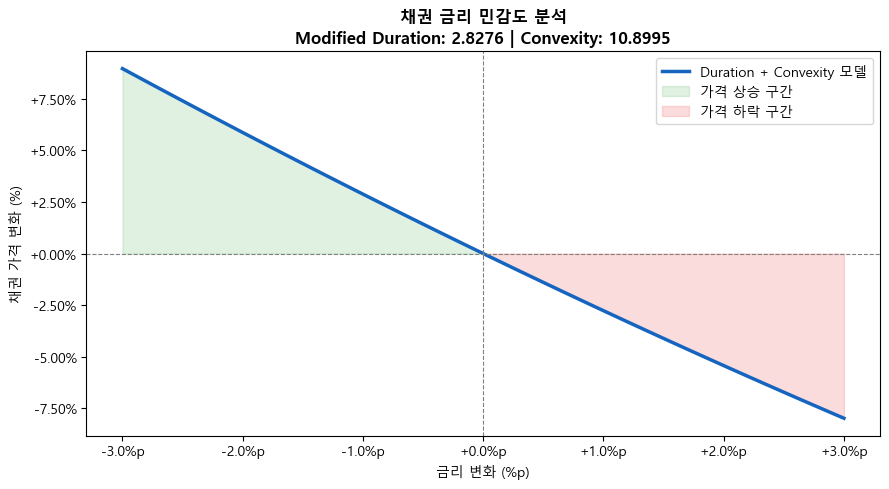

✅ 금리 민감도 차트 저장: data/duration_sensitivity.png


In [ ]:
# Figure 2 — Duration 금리 민감도 단독 차트
# ════════════════════════════════════════════════════════════════
fig2, ax = plt.subplots(figsize=(9, 5))
rate_changes = np.linspace(-0.03, 0.03, 100)
mod_dur      = metrics_s["mod_duration"]
convexity    = metrics_s["convexity"]
price_changes = (-mod_dur * rate_changes + 0.5 * convexity * rate_changes**2) * 100

ax.plot(rate_changes * 100, price_changes, color="#1565C0", linewidth=2.5, label="Duration + Convexity 모델")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.fill_between(rate_changes * 100, price_changes, 0,
                where=price_changes >= 0, color="#66BB6A", alpha=0.2, label="가격 상승 구간")
ax.fill_between(rate_changes * 100, price_changes, 0,
                where=price_changes < 0,  color="#EF5350", alpha=0.2, label="가격 하락 구간")
ax.set_title(f"채권 금리 민감도 분석\nModified Duration: {mod_dur:.4f} | Convexity: {convexity:.4f}",
             fontweight="bold")
ax.set_xlabel("금리 변화 (%p)")
ax.set_ylabel("채권 가격 변화 (%)")
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:+.1f}%p"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.2f}%"))

plt.tight_layout()
plt.savefig("data/duration_sensitivity.png", dpi=150, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print("금리 민감도 차트 저장: data/duration_sensitivity.png")
